In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
import torch
import torch.nn as nn
import torch.nn.functional as F
from mamba_model import Mamba, MambaConfig
import argparse
from DataProcessing import HankelMatrices
import scipy.io
import l4casadi as l4c
from casadi import *
import casadi as cs
from casadi.tools import *

from casadi import *
import casadi as cs
from casadi.tools import *
import time

from plotting import newfig, savefig
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.gridspec as gridspec
from torch.utils.data import DataLoader, TensorDataset

ModuleNotFoundError: No module named 'l4casadi'

Step 0

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

Step 1
Step 2
Step 3
Step 4
Step 5
Step 6
Step 7
Step 8
Step 9
Step 10
Step 11
Step 12
Step 13
Step 14
Step 15
Step 16
Step 17
Step 18
Step 19
Step 20
Step 21
Step 22
Step 23
Step 24
Step 25
Step 26
Step 27
Step 28
Step 29
Step 30
Step 31
Step 32
Step 33
Step 34
Step 35
Step 36
Step 37
Step 38
Step 39
Step 40
Step 41
Step 42
Step 43
Step 44
Step 45
Step 46
Step 47
Step 48
Step 49
Step 50
Step 51
Step 52
Step 53
Step 54
Step 55
Step 56
Step 57
Step 58
Step 59
Step 60
Step 61
Step 62
Step 63
Step 64
Step 65
Step 66
Step 67
Step 68
Step 69
Step 70
Step 71
Step 72
Step 73
Step 74
Step 75
Step 76
Step 77

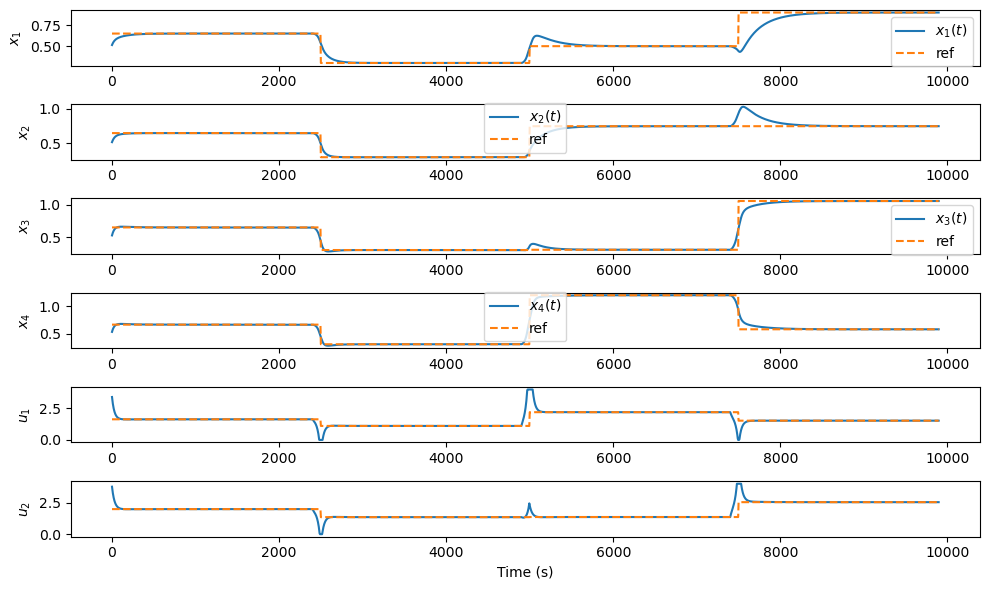

In [1]:
import casadi as ca
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Reference trajectories
ref1 = np.tile([0.650, 0.650, 0.652, 0.664], (500, 1))
ref2 = np.tile([0.300, 0.300, 0.301, 0.306], (500, 1))
ref3 = np.tile([0.500, 0.750, 0.305, 1.200], (500, 1))
ref4 = np.tile([0.900, 0.750, 1.062, 0.579], (500, 1))

uref1 = np.tile([1.637, 1.988], (500, 1))
uref2 = np.tile([1.112, 1.351], (500, 1))
uref3 = np.tile([2.201, 1.361], (500, 1))
uref4 = np.tile([1.528, 2.539], (500, 1))

xref_traj = np.concatenate((ref1, ref2, ref3, ref4), axis=0)
uref_traj = np.concatenate((uref1, uref2, uref3, uref4), axis=0)

# Model parameters
a1, a2, a3, a4 = 1.31e-4, 1.51e-4, 9.27e-5, 8.82e-5
gamma_a, gamma_b = 0.3, 0.4
g, Sc = 9.81, 0.06

params = {'a1': a1, 'a2': a2, 'a3': a3, 'a4': a4, 'gamma_a': gamma_a, 'gamma_b': gamma_b, 'g': g, 'Sc': Sc}

# Dynamics function for simulation
def four_tank(t, x, u1, u2, params):
    x1, x2, x3, x4 = x
    a1, a2, a3, a4 = params['a1'], params['a2'], params['a3'], params['a4']
    Sc, gamma_a, gamma_b = params['Sc'], params['gamma_a'], params['gamma_b']
    g = params['g']
    dx1 = (-a1 / Sc) * np.sqrt(max(0, 2 * g * x1)) + (a3 / Sc) * np.sqrt(max(0, 2 * g * x3)) + gamma_a / (3600 * Sc) * u1
    dx2 = (-a2 / Sc) * np.sqrt(max(0, 2 * g * x2)) + (a4 / Sc) * np.sqrt(max(0, 2 * g * x4)) + gamma_b / (3600 * Sc) * u2
    dx3 = (-a3 / Sc) * np.sqrt(max(0, 2 * g * x3)) + (1 - gamma_b) / (3600 * Sc) * u2
    dx4 = (-a4 / Sc) * np.sqrt(max(0, 2 * g * x4)) + (1 - gamma_a) / (3600 * Sc) * u1
    return [dx1, dx2, dx3, dx4]

# CasADi dynamics
def casadi_dynamics(x, u):
    h1, h2, h3, h4 = x[0], x[1], x[2], x[3]
    h1_dot = -a1/Sc*ca.sqrt(2*g*ca.fmax(h1, 0)) + a3/Sc*ca.sqrt(2*g*ca.fmax(h3, 0)) + gamma_a/(3600*Sc)*u[0]
    h2_dot = -a2/Sc*ca.sqrt(2*g*ca.fmax(h2, 0)) + a4/Sc*ca.sqrt(2*g*ca.fmax(h4, 0)) + gamma_b/(3600*Sc)*u[1]
    h3_dot = -a3/Sc*ca.sqrt(2*g*ca.fmax(h3, 0)) + (1-gamma_b)/(3600*Sc)*u[1]
    h4_dot = -a4/Sc*ca.sqrt(2*g*ca.fmax(h4, 0)) + (1-gamma_a)/(3600*Sc)*u[0]
    return ca.vertcat(h1_dot, h2_dot, h3_dot, h4_dot)

# MPC setup
Ts = 5
N = 20
nx, nu = 4, 2
Q = np.diag([1, 1, 1, 1])
R = np.diag([0.01, 0.01])

opti = ca.Opti()
X = opti.variable(nx, N+1)
U = opti.variable(nu, N+1)
x0 = opti.parameter(nx)
ref = opti.parameter(nx, N+1)
uref = opti.parameter(nu, N+1)

cost = 0
for k in range(N):
    x_err = X[:,k] - ref[:,k]
    u_err = U[:,k] - uref[:,k]
    cost += ca.mtimes([x_err.T, Q, x_err]) + ca.mtimes([u_err.T, R, u_err])
    x_next = X[:,k] + Ts * casadi_dynamics(X[:,k], U[:,k])
    opti.subject_to(X[:,k+1] == x_next)

# Constraints
opti.subject_to(X[:,0] == x0)
opti.subject_to(opti.bounded(0, X, np.inf))  # ensure states are non-negative
opti.subject_to(opti.bounded(0, U, 4.0))     # input bounds
opti.minimize(cost)

# Solver
opti.solver('ipopt', {
    'ipopt.print_level': 0,
    'print_time': 0,
    'ipopt.tol': 1e-6
})

# Simulation loop
x_vals, u_vals = [], []
x_current = np.array([0.5, 0.5, 0.5, 0.5])

for i in range(len(xref_traj) - N):
    print(f"Step {i}")
    REF = xref_traj[i:i+N+1,:].T
    UREF = uref_traj[i:i+N+1,:].T

    opti.set_value(x0, x_current)
    opti.set_value(ref, REF)
    opti.set_value(uref, UREF)

    # Set initial guesses
    opti.set_initial(X, np.tile(x_current.reshape(-1,1), (1, N+1)))
    last_u = u_vals[-1] if u_vals else np.array([1.0, 1.0])
    opti.set_initial(U, np.tile(last_u.reshape(-1,1), (1, N+1)))

    try:
        sol = opti.solve()
    except RuntimeError as e:
        print(f"Solver failed at step {i}: {e}")
        break

    u_mpc = sol.value(U[:, 0])
    sol_ivp = solve_ivp(lambda t, x: four_tank(t, x, u_mpc[0], u_mpc[1], params), [0, Ts], x_current)
    x_next = sol_ivp.y[:, -1]

    x_vals.append(x_next)
    u_vals.append(u_mpc)
    x_current = x_next

# Convert logs
x_vals = np.array(x_vals)
u_vals = np.array(u_vals)
t_vec = np.arange(len(x_vals)) * Ts

# Plotting
plt.figure(figsize=(10, 6))
for i in range(4):
    plt.subplot(6, 1, i+1)
    plt.plot(t_vec, x_vals[:, i], label=f'$x_{i+1}(t)$')
    plt.plot(t_vec, xref_traj[:len(x_vals), i], '--', label='ref')
    plt.ylabel(f'$x_{i+1}$')
    plt.legend()
plt.subplot(6, 1, 5)
plt.plot(t_vec, u_vals[:,0])
plt.plot(t_vec, uref_traj[:len(u_vals), 0], '--', label='ref')
plt.ylabel('$u_1$')
plt.subplot(6, 1, 6)
plt.plot(t_vec, u_vals[:,1])
plt.plot(t_vec, uref_traj[:len(u_vals), 1], '--', label='ref')
plt.ylabel('$u_2$')
plt.xlabel('Time (s)')
plt.tight_layout()
plt.show()


In [26]:
xref_traj.shape
x_vals.shape
y_mamba.shape


(2000, 4)

In [9]:
## Import Data
filename = "ZOH_D8_dstate8_Conv4_Q100"
y_mamba = np.load("ControllerOutput/yvec_"+filename+".npy")
u1 = np.load("ControllerOutput/u1_"+filename+".npy")
u2 = np.load("ControllerOutput/u2_"+filename+".npy")
y_mamba = np.array(y_mamba)
u1 = np.array(u1)
u2 = np.array(u2)
## Generate Reference
#Sampling Time
Ts = 5

# Simulation time
time_range = 24

# Simulation steps
L = round(time_range/Ts)

# Init time
t = np.arange(L+1)*Ts

#Choose the reference
f = 0.2  # Frequency in Hz
A = 2
#Model Variables
N = 10
Tini = 3

# ref =  A*np.sin(2*np.pi*f*t)

abs_error_mamba = np.abs(y_mamba-xref_traj[0:len(y_mamba)])
abs_error_NMPC = np.abs(x_vals-xref_traj[0:len(x_vals)])

In [10]:
print("Absolute Error Mamba: ", np.sum(abs_error_mamba))
print("Absolute Error NMPC: ", np.sum(abs_error_NMPC))

Absolute Error Mamba:  213.21001046467288
Absolute Error NMPC:  116.63042490331222


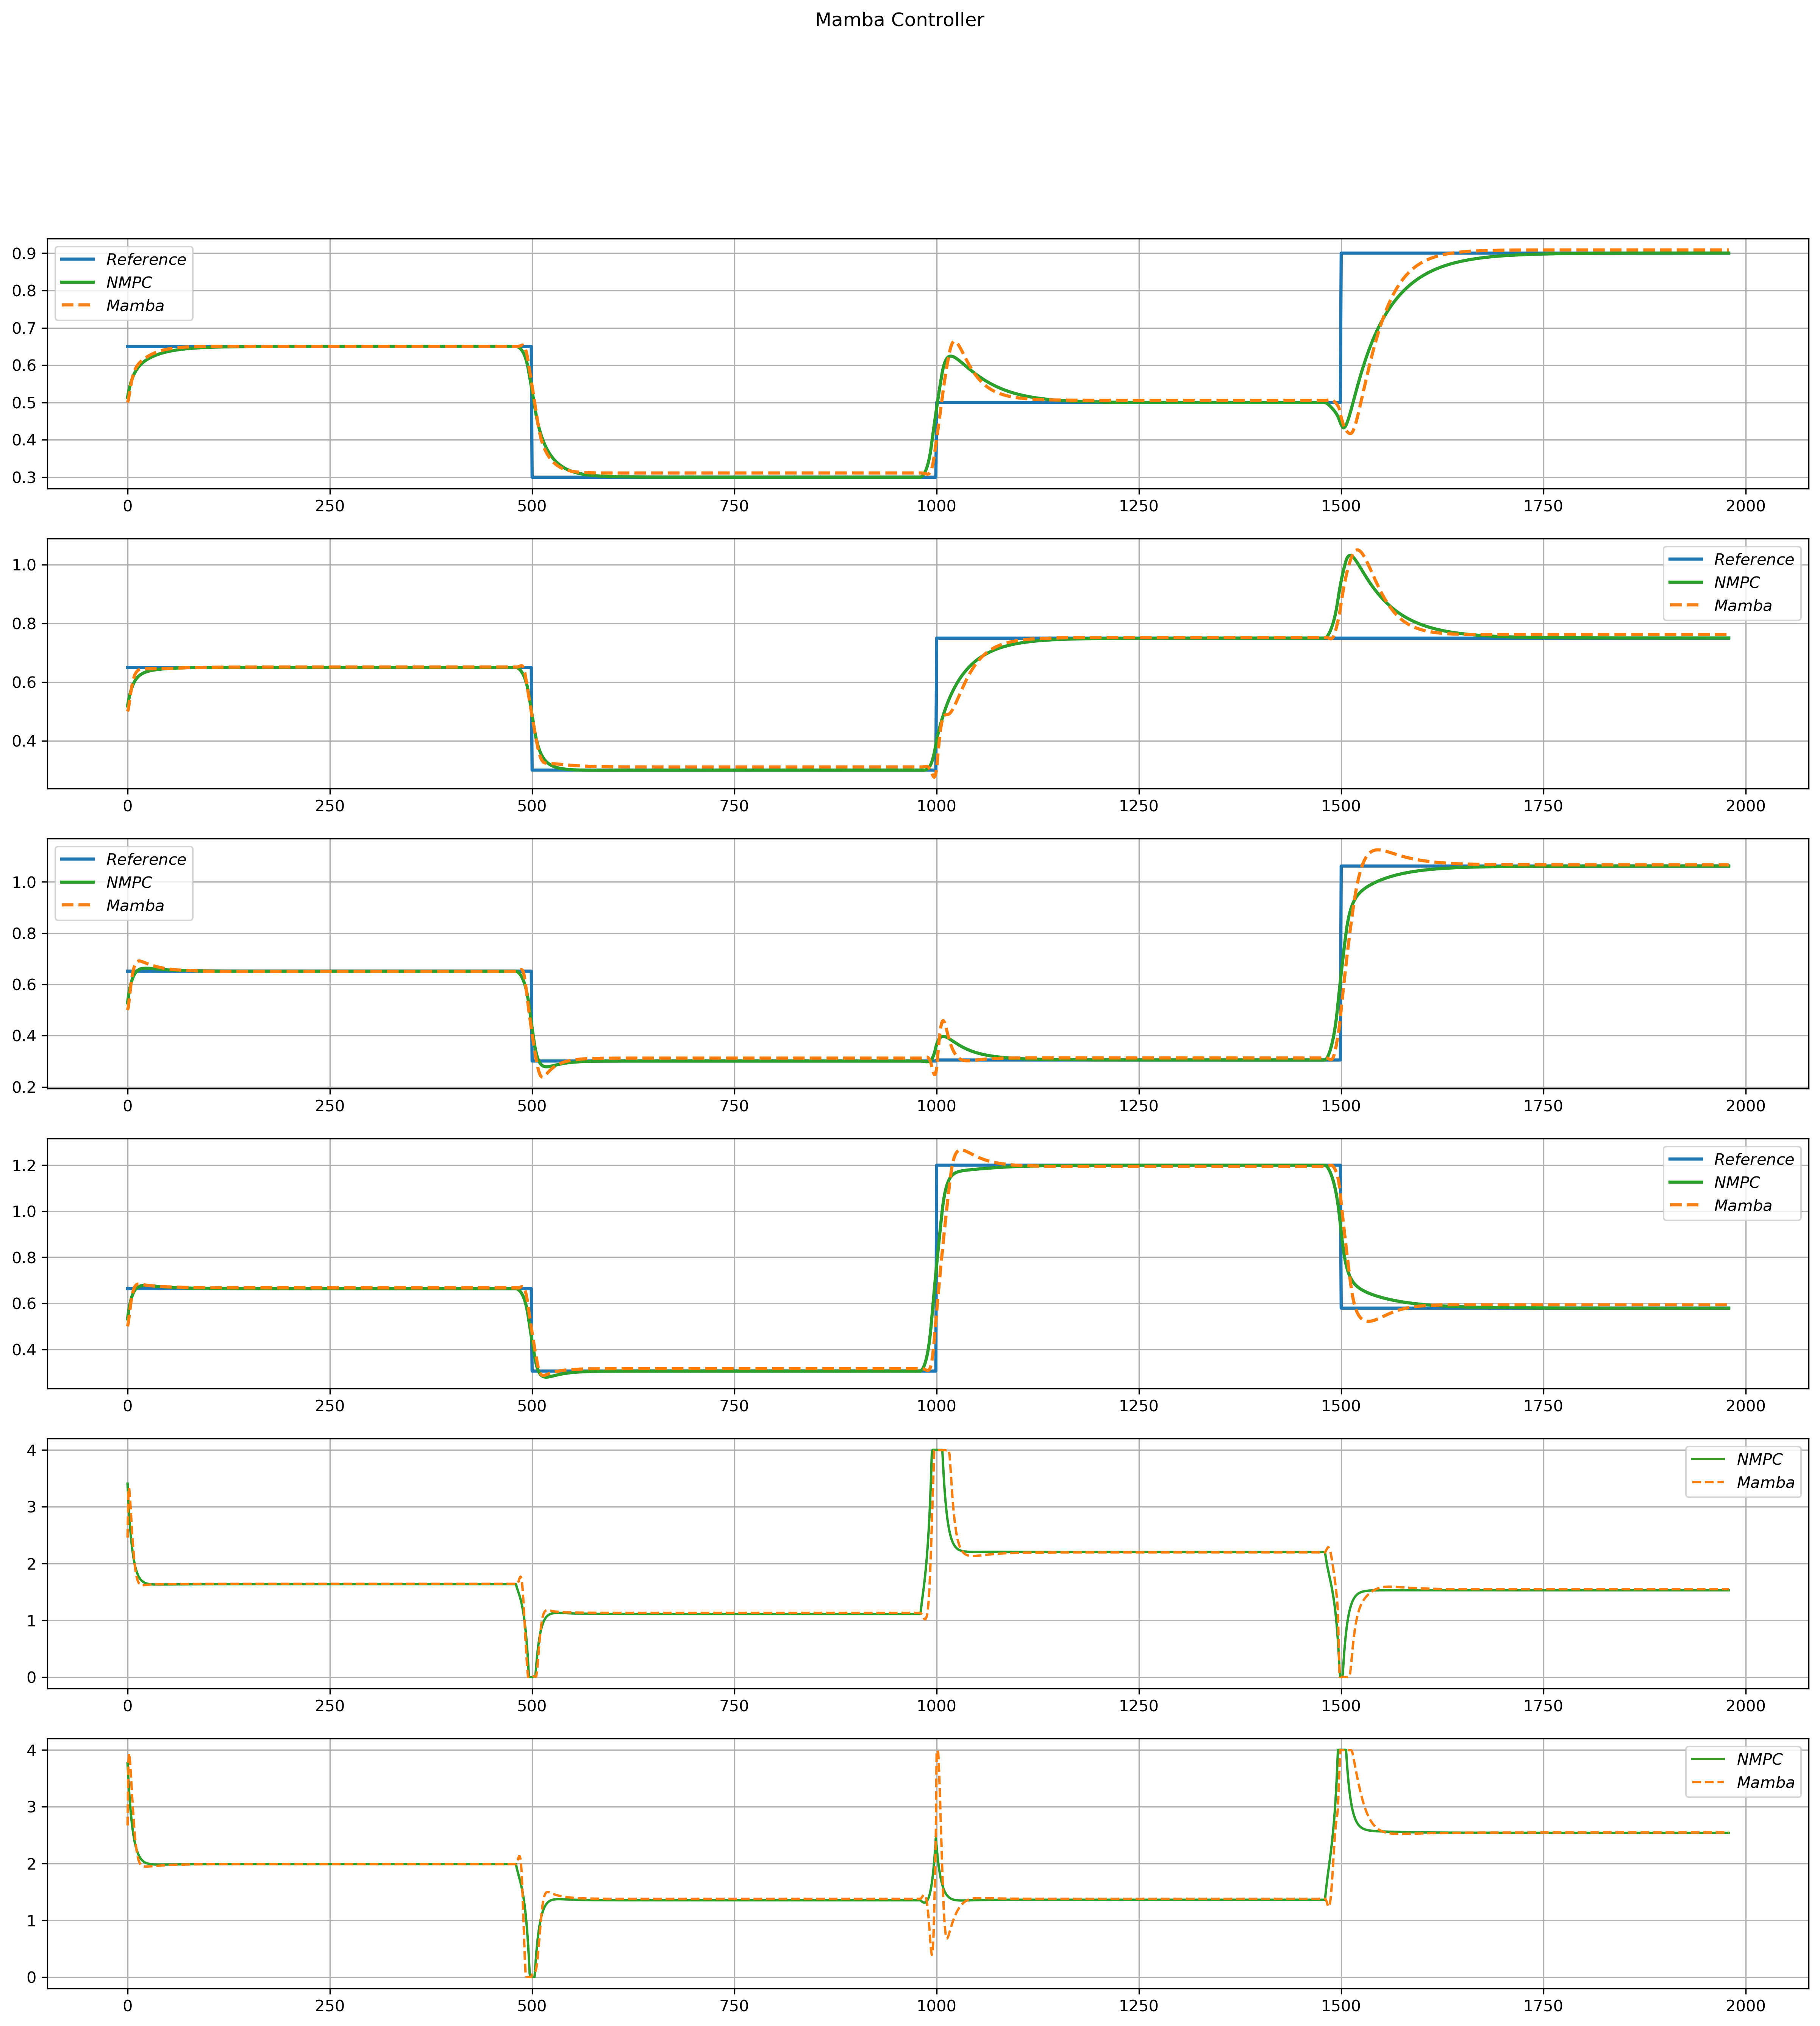

In [27]:
fig, axs = plt.subplots(6,  figsize=(20, 20), dpi=300)

fig.suptitle("Mamba Controller")
axs[0].plot(xref_traj[:x_vals.shape[0],0], '-', color = 'tab:blue' ,lw=2.0, label="$Reference$")
axs[0].plot(x_vals[:,0],'-', color = 'tab:green',lw=2.0, label = "$NMPC$")
axs[0].plot(y_mamba[:1980,0], '--', color = 'tab:orange', lw=2.0,label = "$Mamba$")
axs[0].legend()
axs[0].grid()

axs[1].plot(xref_traj[:x_vals.shape[0],1], '-', color = 'tab:blue' ,lw=2.0, label="$Reference$")
axs[1].plot(x_vals[:,1],'-', color = 'tab:green',lw=2.0, label = "$NMPC$")
axs[1].plot(y_mamba[:1980,1], '--', color = 'tab:orange', lw=2.0,label = "$Mamba$")
axs[1].legend()
axs[1].grid()

axs[2].plot(xref_traj[:x_vals.shape[0],2], '-', color = 'tab:blue' ,lw=2.0, label="$Reference$")
axs[2].plot(x_vals[:,2],'-', color = 'tab:green',lw=2.0, label = "$NMPC$")
axs[2].plot(y_mamba[:1980,2], '--', color = 'tab:orange', lw=2.0,label = "$Mamba$")
axs[2].legend()
axs[2].grid()

axs[3].plot(xref_traj[:x_vals.shape[0],3], '-', color = 'tab:blue' ,lw=2.0, label="$Reference$")
axs[3].plot(x_vals[:,3],'-', color = 'tab:green',lw=2.0, label = "$NMPC$")
axs[3].plot(y_mamba[:1980,3], '--', color = 'tab:orange', lw=2.0,label = "$Mamba$")
axs[3].legend()
axs[3].grid()



axs[4].plot(u_vals[:,0], '-', color = 'tab:green', label = "$NMPC$")
axs[4].plot(u1[1:] ,  '--',color = 'tab:orange', label = "$Mamba$")
axs[4].legend()
axs[4].grid()


axs[5].plot(u_vals[:,1], '-', color = 'tab:green', label = "$NMPC$")
axs[5].plot(u2[1:] ,  '--',color = 'tab:orange', label = "$Mamba$")
axs[5].legend()
axs[5].grid()

# axs[2].plot(abs_error_NMPC, '-', color = 'tab:green', label = "$NMPC$")
# axs[2].plot(abs_error_mamba, '--', color = 'tab:orange', label = "$Mamba$")
# axs[2].grid()
# axs[2].legend()
# axs[0].set(ylabel="$y$")
# #axs[1].set(ylabel="theta")
# axs[1].set(ylabel="$u$")
# axs[2].set(ylabel="$|Error|$")
# axs[1].grid()

plt.show()

fig.savefig("MambaController"+filename+".png", format='png', dpi=300)

####### Row 0: u(t,x) ##################    
# gs0 = gridspec.GridSpec(1,1)
# #gs0.update(top=1-0.06, bottom=1-1/3, left=0.15, right=0.85, wspace=0)
# ax = plt.subplot(gs0[:, :])
# ax.semilogy(ref[:230], 'b', lw=2.0, label="validation loss")
# ax.semilogy(x1, '-b', lw=2.0, label="training loss")
# ax.set_xlabel('$epoch$')
# ax.set_ylabel('$loss$')
# ax.grid()
# ax.legend(frameon=False, loc = 'best')
# ax.set_title('Mamba', fontsize = 10)
# #ax.set_xlim([0,1.2])
# #ax.set_ylim([-1.1,1.1])
# #ax.axis('square')
# plt.savefig("loss.png", dpi=300)
# plt.show()

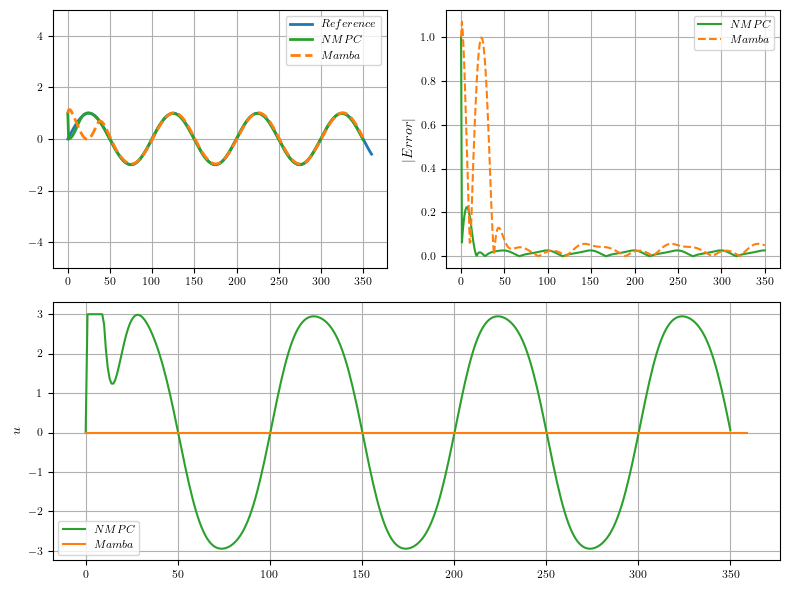

In [16]:
# Create a figure
fig = plt.figure(figsize=(8, 6)) # Adjust figsize as needed

# Define the grid structure: 2 rows, 2 columns
# We'll use height_ratios to make the bottom plot potentially taller/shorter if desired
gs = gridspec.GridSpec(2, 2, figure=fig) #, height_ratios=[1, 1])

# Create the first subplot (top-left) - occupies row 0, column 0
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(ref, '-', color = 'tab:blue' ,lw=2.0, label="$Reference$")
ax1.plot(yvec,'-', color = 'tab:green',lw=2.0, label = "$NMPC$")
ax1.plot(y_mamba, '--', color = 'tab:orange', lw=2.0,label = "$Mamba$")
ax1.legend()
ax1.grid()
ax1.set_ylim(-5, 5)

# Create the second subplot (top-right) - occupies row 0, column 1
ax2 = fig.add_subplot(gs[1, :])
ax2.plot(uvec, color = 'tab:green', label = "$NMPC$")
ax2.plot(u ,'-', color = 'tab:orange', label = "$Mamba$")
ax2.legend()
ax2.grid()
ax2.set(ylabel="$u$")

# Create the third subplot (bottom, spanning both columns)
# It occupies row 1, and columns 0 *through* 1 (using slicing)
ax3 = fig.add_subplot(gs[0, 1]) # The ':' means span all columns in this row
ax3.plot(abs_error_NMPC,  color = 'tab:green', label = "$NMPC$")
ax3.plot(abs_error_mamba, '--',color = 'tab:orange', label = "$Mamba$")
ax3.grid()
ax3.legend()
ax3.set(ylabel="$|Error|$")

# Adjust layout to prevent overlapping titles/labels
plt.tight_layout()


# Show the plot
plt.show()
fig.savefig("MambaController_VDP_"+filename+".png", format='png', dpi=300)